## Stage 03: Experiment Tracking — Employee Attrition

This notebook trains and compares multiple classification models for employee attrition prediction, tracking all runs with MLflow.

### MLflow setup
- **Tracking server:** Local server (same as scenario-2 from class)
- **Backend store:** SQLite (`backend.db`)
- **Artifacts store:** Local filesystem

### How to run
1. Start the MLflow server in a terminal:
   ```bash
   mlflow server --backend-store-uri sqlite:///backend.db --host 127.0.0.1 --port 5001
   ```
2. Run this notebook top to bottom
3. Open http://localhost:5000 to compare runs

### What this notebook does
1. Load processed train/test data from Stage 02
2. Naïve baseline — always predict No
3. Simple Logistic Regression baseline — 4 features only
4. Train all 4 candidate models with 5-fold CV and class weights
5. Log every run to MLflow (params, metrics, model artifact)
6. Compare results and select the best model
7. Register the best model in the MLflow Model Registry
8. Write `run_id.txt` for Stage 04

## Imports

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Evaluation
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    f1_score, roc_auc_score, precision_score,
    recall_score, log_loss, classification_report,
    ConfusionMatrixDisplay
)

# MLflow
import mlflow
import mlflow.sklearn
import mlflow.xgboost
from mlflow.tracking import MlflowClient

warnings.filterwarnings('ignore')
print('Imports done.')

Imports done.


## Configuration

In [57]:
MLFLOW_TRACKING_URI = 'http://127.0.0.1:5001'
EXPERIMENT_NAME     = 'employee-attrition'
RANDOM_STATE        = 42
CV_FOLDS            = 5

# Class imbalance: 1233 No / 237 Yes = 5.20 ratio
# Used by XGBoost natively; others use class_weight='balanced'
SCALE_POS_WEIGHT = 5.20

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)
print(f'Tracking URI : {mlflow.get_tracking_uri()}')
print(f'Experiment   : {EXPERIMENT_NAME}')

Tracking URI : http://127.0.0.1:5001
Experiment   : employee-attrition


## Load Processed Data from Stage 02

In [58]:
train_df = pd.read_csv('../data/processed/train.csv')
test_df = pd.read_csv('../data/processed/test.csv')

X_train = train_df.drop(columns=['Attrition'])
y_train = train_df['Attrition']
X_test  = test_df.drop(columns=['Attrition'])
y_test  = test_df['Attrition']

print(f'Train: {X_train.shape}  |  attrition rate: {y_train.mean()*100:.1f}%')
print(f'Test : {X_test.shape}   |  attrition rate: {y_test.mean()*100:.1f}%')
print(f'Features: {X_train.shape[1]}')

Train: (1176, 53)  |  attrition rate: 16.2%
Test : (294, 53)   |  attrition rate: 16.0%
Features: 53


## Cross-Validation Helper

All candidate models use the same stratified 5-fold CV. We score F1, ROC-AUC, Precision, and Recall on each fold and report the mean.

In [59]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

SCORING = ['f1', 'roc_auc', 'precision', 'recall']

def run_cv(model, X, y):
    """Run stratified k-fold CV and return mean scores."""
    results = cross_validate(model, X, y, cv=cv, scoring=SCORING)
    return {
        'f1'       : results['test_f1'].mean(),
        'roc_auc'  : results['test_roc_auc'].mean(),
        'precision': results['test_precision'].mean(),
        'recall'   : results['test_recall'].mean(),
    }

print('CV helper ready.')

CV helper ready.


## Baseline 1: Naïve — Always Predict No Attrition

In [60]:
y_naive = np.zeros(len(y_test), dtype=int)

naive_f1        = f1_score(y_test, y_naive, zero_division=0)
naive_recall    = recall_score(y_test, y_naive, zero_division=0)
naive_precision = precision_score(y_test, y_naive, zero_division=0)
naive_accuracy  = (y_naive == y_test).mean()

print('=== Naïve Baseline: Always Predict No ===')
print(f'  Accuracy : {naive_accuracy*100:.1f}%  <- misleading')
print(f'  F1       : {naive_f1:.3f}  <- floor to beat')
print(f'  Recall   : {naive_recall:.3f}')
print(f'  Precision: {naive_precision:.3f}')

with mlflow.start_run(run_name='naive-baseline'):
    mlflow.log_metric('f1',        naive_f1)
    mlflow.log_metric('roc_auc',   0.5)      # random classifier AUC
    mlflow.log_metric('precision', naive_precision)
    mlflow.log_metric('recall',    naive_recall)
    mlflow.set_tag('model_type', 'NaiveBaseline')
    mlflow.set_tag('description', 'Always predict No attrition')
    print('Logged to MLflow.')

=== Naïve Baseline: Always Predict No ===
  Accuracy : 84.0%  <- misleading
  F1       : 0.000  <- floor to beat
  Recall   : 0.000
  Precision: 0.000
Logged to MLflow.
🏃 View run naive-baseline at: http://127.0.0.1:5001/#/experiments/1/runs/e8742c4c42984901be9948187ed3b6da
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1


## Baseline 2: Simple Logistic Regression — 4 Domain Features Only

Per the proposal: OverTime, MonthlyIncome, YearsAtCompany, JobSatisfaction. If candidate models cannot beat this substantially, that is itself an important finding.

In [61]:
BASELINE_FEATURES = ['OverTime', 'MonthlyIncome', 'YearsAtCompany', 'JobSatisfaction']

lr_baseline = LogisticRegression(
    class_weight='balanced',
    random_state=RANDOM_STATE,
    max_iter=1000
)

baseline_scores = run_cv(lr_baseline, X_train[BASELINE_FEATURES], y_train)

print('=== Baseline 2: Logistic Regression (4 features) ===')
for metric, val in baseline_scores.items():
    print(f'  {metric:<10}: {val:.3f}')

with mlflow.start_run(run_name='lr-baseline-4features'):
    mlflow.log_params({
        'model'         : 'LogisticRegression',
        'features'      : '4-domain-only',
        'class_weight'  : 'balanced',
        'cv_folds'      : CV_FOLDS,
    })
    mlflow.log_metrics(baseline_scores)
    mlflow.set_tag('model_type', 'LogisticRegression')
    mlflow.set_tag('description', 'Baseline: 4 domain features only')
    print('Logged to MLflow.')

=== Baseline 2: Logistic Regression (4 features) ===
  f1        : 0.410
  roc_auc   : 0.735
  precision : 0.296
  recall    : 0.668
Logged to MLflow.
🏃 View run lr-baseline-4features at: http://127.0.0.1:5001/#/experiments/1/runs/3230b09082294e9ba81ae26f5719f68e
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1


## Candidate Models

All 4 candidates use:
- Full feature set (53 features including 4 engineered)
- `class_weight='balanced'` (or `scale_pos_weight` for XGBoost)
- Stratified 5-fold cross-validation
- Logged to MLflow with params, CV metrics, and model artifact

### Candidate 1: Logistic Regression (Full Features)

In [62]:
lr_params = {
    'C'            : 0.1,
    'penalty'      : 'l2',
    'class_weight' : 'balanced',
    'max_iter'     : 1000,
    'random_state' : RANDOM_STATE,
    'solver'       : 'lbfgs',
}

lr_model = LogisticRegression(**lr_params)
lr_scores = run_cv(lr_model, X_train, y_train)

print('=== Logistic Regression (full features) ===')
for metric, val in lr_scores.items():
    print(f'  {metric:<10}: {val:.3f}')

# Fit on full train set and log model artifact
lr_model.fit(X_train, y_train)

with mlflow.start_run(run_name='logistic-regression') as run:
    mlflow.log_params({**lr_params, 'cv_folds': CV_FOLDS, 'n_features': X_train.shape[1]})
    mlflow.log_metrics(lr_scores)
    mlflow.set_tag('model_type', 'LogisticRegression')
    mlflow.set_tag('description', 'LR with L2 regularization, full feature set')
    mlflow.sklearn.log_model(lr_model, name='model', input_example=X_train.iloc[:1])
    lr_run_id = run.info.run_id
    print(f'Run ID: {lr_run_id}')

=== Logistic Regression (full features) ===
  f1        : 0.497
  roc_auc   : 0.831
  precision : 0.376
  recall    : 0.742


2026/03/18 16:24:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run ID: 64b11957788d49b2b2a835b728936966
🏃 View run logistic-regression at: http://127.0.0.1:5001/#/experiments/1/runs/64b11957788d49b2b2a835b728936966
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1


### Candidate 2: Random Forest

In [63]:
rf_params = {
    'n_estimators' : 200,
    'max_depth'    : 8,
    'class_weight' : 'balanced',
    'random_state' : RANDOM_STATE,
    'n_jobs'       : -1,
}

rf_model = RandomForestClassifier(**rf_params)
rf_scores = run_cv(rf_model, X_train, y_train)

print('=== Random Forest ===')
for metric, val in rf_scores.items():
    print(f'  {metric:<10}: {val:.3f}')

rf_model.fit(X_train, y_train)

with mlflow.start_run(run_name='random-forest') as run:
    mlflow.log_params({**rf_params, 'cv_folds': CV_FOLDS, 'n_features': X_train.shape[1]})
    mlflow.log_metrics(rf_scores)
    mlflow.set_tag('model_type', 'RandomForest')
    mlflow.set_tag('description', 'RF with balanced class weight')
    mlflow.sklearn.log_model(rf_model, name='model', input_example=X_train.iloc[:1])
    rf_run_id = run.info.run_id
    print(f'Run ID: {rf_run_id}')

2026/03/18 16:24:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


=== Random Forest ===
  f1        : 0.387
  roc_auc   : 0.805
  precision : 0.737
  recall    : 0.268
Run ID: 3d95737d6e4848d8b9886b30e99155ae
🏃 View run random-forest at: http://127.0.0.1:5001/#/experiments/1/runs/3d95737d6e4848d8b9886b30e99155ae
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1


### Candidate 3: XGBoost

In [64]:
xgb_params = {
    'n_estimators'    : 200,
    'max_depth'       : 4,
    'learning_rate'   : 0.05,
    'scale_pos_weight': SCALE_POS_WEIGHT,   # handles class imbalance natively
    'subsample'       : 0.8,
    'colsample_bytree': 0.8,
    'random_state'    : RANDOM_STATE,
    'eval_metric'     : 'logloss',
    'verbosity'       : 0,
}

xgb_model = XGBClassifier(**xgb_params)
xgb_scores = run_cv(xgb_model, X_train, y_train)

print('=== XGBoost ===')
for metric, val in xgb_scores.items():
    print(f'  {metric:<10}: {val:.3f}')

xgb_model.fit(X_train, y_train)

with mlflow.start_run(run_name='xgboost') as run:
    mlflow.log_params({**xgb_params, 'cv_folds': CV_FOLDS, 'n_features': X_train.shape[1]})
    mlflow.log_metrics(xgb_scores)
    mlflow.set_tag('model_type', 'XGBoost')
    mlflow.set_tag('description', 'XGBoost with scale_pos_weight for imbalance')
    mlflow.xgboost.log_model(xgb_model, name='model', input_example=X_train.iloc[:1])
    xgb_run_id = run.info.run_id
    print(f'Run ID: {xgb_run_id}')

=== XGBoost ===
  f1        : 0.523
  roc_auc   : 0.811
  precision : 0.568
  recall    : 0.489
Run ID: d6169996953c4adeb286e4a699f5e0ac
🏃 View run xgboost at: http://127.0.0.1:5001/#/experiments/1/runs/d6169996953c4adeb286e4a699f5e0ac
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1


### Candidate 4: SVM (RBF Kernel)

In [65]:
svm_params = {
    'C'           : 1.0,
    'kernel'      : 'rbf',
    'class_weight': 'balanced',
    'probability' : True,   # needed for ROC-AUC and risk probabilities
    'random_state': RANDOM_STATE,
}

svm_model = SVC(**svm_params)
svm_scores = run_cv(svm_model, X_train, y_train)

print('=== SVM (RBF kernel) ===')
for metric, val in svm_scores.items():
    print(f'  {metric:<10}: {val:.3f}')

svm_model.fit(X_train, y_train)

with mlflow.start_run(run_name='svm-rbf') as run:
    mlflow.log_params({**svm_params, 'cv_folds': CV_FOLDS, 'n_features': X_train.shape[1]})
    mlflow.log_metrics(svm_scores)
    mlflow.set_tag('model_type', 'SVM')
    mlflow.set_tag('description', 'SVM RBF kernel, balanced class weight')
    mlflow.sklearn.log_model(svm_model, name='model', input_example=X_train.iloc[:1])
    svm_run_id = run.info.run_id
    print(f'Run ID: {svm_run_id}')

=== SVM (RBF kernel) ===
  f1        : 0.540
  roc_auc   : 0.815
  precision : 0.503
  recall    : 0.589


2026/03/18 16:24:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run ID: 05866f5872014f1da22d400cfb853b5d
🏃 View run svm-rbf at: http://127.0.0.1:5001/#/experiments/1/runs/05866f5872014f1da22d400cfb853b5d
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1


## Results Comparison

In [66]:
results = pd.DataFrame({
    'Naive Baseline'    : {'f1': naive_f1, 'roc_auc': 0.5,
                           'precision': naive_precision, 'recall': naive_recall},
    'LR (4 features)'   : baseline_scores,
    'Logistic Regression': lr_scores,
    'Random Forest'      : rf_scores,
    'XGBoost'            : xgb_scores,
    'SVM (RBF)'          : svm_scores,
}).T.round(3)

results = results.sort_values('f1', ascending=False)
print('=== Model Comparison (sorted by F1) ===')
print(results.to_string())

=== Model Comparison (sorted by F1) ===
                        f1  roc_auc  precision  recall
SVM (RBF)            0.540    0.815      0.503   0.589
XGBoost              0.523    0.811      0.568   0.489
Logistic Regression  0.497    0.831      0.376   0.742
LR (4 features)      0.410    0.735      0.296   0.668
Random Forest        0.387    0.805      0.737   0.268
Naive Baseline       0.000    0.500      0.000   0.000


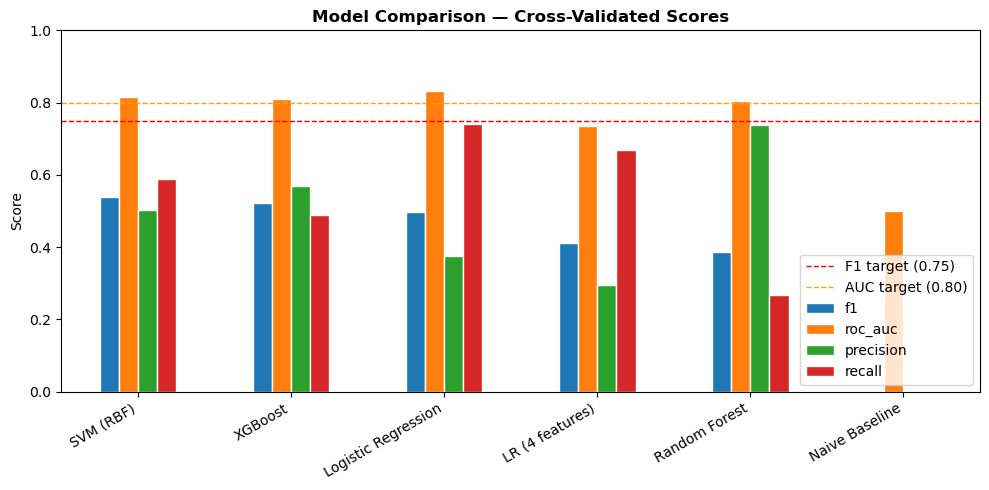

In [67]:
fig, ax = plt.subplots(figsize=(10, 5))
results[['f1', 'roc_auc', 'precision', 'recall']].plot(
    kind='bar', ax=ax, edgecolor='white'
)
ax.axhline(y=0.75, color='red', linestyle='--', linewidth=1, label='F1 target (0.75)')
ax.axhline(y=0.80, color='orange', linestyle='--', linewidth=1, label='AUC target (0.80)')
ax.set_title('Model Comparison — Cross-Validated Scores', fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../plots/07_model_comparison.png', bbox_inches='tight')
plt.show()

## Select Best Model & Evaluate on Test Set

Best model = highest mean cross-validated F1 on the attrition class. However interpretability also plays a role to pick the best model.

In [68]:
# Map model names to fitted objects and run IDs
model_registry = {
    'Logistic Regression': (lr_model,  lr_run_id),
    'Random Forest'      : (rf_model,  rf_run_id),
    'XGBoost'            : (xgb_model, xgb_run_id),
    'SVM (RBF)'          : (svm_model, svm_run_id),
}

# Pick best by CV F1 (exclude baselines)
candidate_results = results.loc[list(model_registry.keys())]
best_name = candidate_results['f1'].idxmax()
best_model, best_run_id = model_registry[best_name]

print(f'Best model: {best_name}')
print(f'Run ID    : {best_run_id}')
print(f'CV F1     : {candidate_results.loc[best_name, "f1"]:.3f}')

Best model: SVM (RBF)
Run ID    : 05866f5872014f1da22d400cfb853b5d
CV F1     : 0.540


In [69]:
# Final evaluation on the held-out test set
y_pred      = best_model.predict(X_test)
y_pred_prob = best_model.predict_proba(X_test)[:, 1]

test_f1        = f1_score(y_test, y_pred)
test_roc_auc   = roc_auc_score(y_test, y_pred_prob)
test_precision = precision_score(y_test, y_pred)
test_recall    = recall_score(y_test, y_pred)
test_logloss   = log_loss(y_test, y_pred_prob)

print(f'=== {best_name} — Test Set Results ===')
print(f'  F1        : {test_f1:.3f}   (target: >= 0.75)')
print(f'  ROC-AUC   : {test_roc_auc:.3f}   (target: >= 0.80)')
print(f'  Precision : {test_precision:.3f}')
print(f'  Recall    : {test_recall:.3f}')
print(f'  Log Loss  : {test_logloss:.3f}')
print()
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Left']))

=== SVM (RBF) — Test Set Results ===
  F1        : 0.505   (target: >= 0.75)
  ROC-AUC   : 0.796   (target: >= 0.80)
  Precision : 0.450
  Recall    : 0.574
  Log Loss  : 0.348

              precision    recall  f1-score   support

      Stayed       0.91      0.87      0.89       247
        Left       0.45      0.57      0.50        47

    accuracy                           0.82       294
   macro avg       0.68      0.72      0.70       294
weighted avg       0.84      0.82      0.83       294



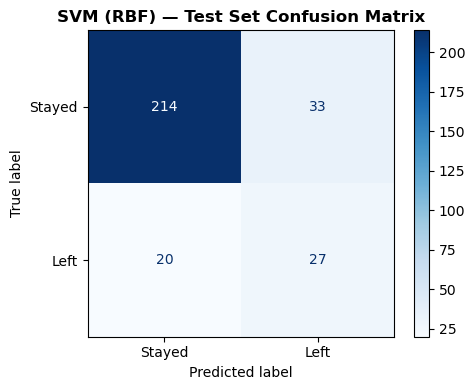

In [70]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Stayed', 'Left'],
    cmap='Blues', ax=ax
)
ax.set_title(f'{best_name} — Test Set Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/08_confusion_matrix.png', bbox_inches='tight')
plt.show()

In [71]:
# Log test metrics back to the best model's run
with mlflow.start_run(run_id=best_run_id):
    mlflow.log_metric('test_f1',        test_f1)
    mlflow.log_metric('test_roc_auc',   test_roc_auc)
    mlflow.log_metric('test_precision', test_precision)
    mlflow.log_metric('test_recall',    test_recall)
    mlflow.log_metric('test_log_loss',  test_logloss)
    mlflow.log_artifact('../plots/08_confusion_matrix.png')
    mlflow.set_tag('best_model', 'true')
    print(f'Test metrics logged to run {best_run_id}')

Test metrics logged to run 05866f5872014f1da22d400cfb853b5d
🏃 View run svm-rbf at: http://127.0.0.1:5001/#/experiments/1/runs/05866f5872014f1da22d400cfb853b5d
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1


## Feature Importance (Best Model)

In [72]:
feature_names = list(X_train.columns)

# Get feature importances — works for RF and XGBoost
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    fi = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(8, 6))
    fi.sort_values().plot(kind='barh', ax=ax, color='#4C72B0', edgecolor='white')
    ax.set_title(f'Top 15 Feature Importances — {best_name}', fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.savefig('../plots/09_feature_importance.png', bbox_inches='tight')
    plt.show()

    with mlflow.start_run(run_id=best_run_id):
        mlflow.log_artifact('../plots/09_feature_importance.png')

elif hasattr(best_model, 'coef_'):
    # Logistic regression: use absolute coefficient values
    coef = pd.Series(np.abs(best_model.coef_[0]), index=feature_names)
    fi = coef.sort_values(ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(8, 6))
    fi.sort_values().plot(kind='barh', ax=ax, color='#4C72B0', edgecolor='white')
    ax.set_title(f'Top 15 Coefficients (abs) — {best_name}', fontweight='bold')
    ax.set_xlabel('|Coefficient|')
    plt.tight_layout()
    plt.savefig('../plots/09_feature_importance.png', bbox_inches='tight')
    plt.show()

    with mlflow.start_run(run_id=best_run_id):
        mlflow.log_artifact('../plots/09_feature_importance.png')
else:
    print(f'{best_name} does not expose feature importances directly.')

SVM (RBF) does not expose feature importances directly.


## Register Best Model in MLflow Model Registry

Same pattern as scenario-2 from class — register the best run, then tag it as Production.

In [73]:
client = MlflowClient(MLFLOW_TRACKING_URI)

model_uri = f'runs:/{best_run_id}/model'
registered = mlflow.register_model(model_uri=model_uri, name='attrition-classifier')

print(f'Registered model : attrition-classifier')
print(f'Version          : {registered.version}')
print(f'Status           : {registered.status}')

Successfully registered model 'attrition-classifier'.
2026/03/18 16:24:11 WARNING mlflow.tracking._model_registry.fluent: Run with id 05866f5872014f1da22d400cfb853b5d has no artifacts at artifact path 'model', registering model based on models:/m-19f6a4f421df4e5b9755852488e3539e instead
2026/03/18 16:24:11 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: attrition-classifier, version 1


Registered model : attrition-classifier
Version          : 1
Status           : READY


Created version '1' of model 'attrition-classifier'.


In [74]:
# Tag this version as Production
client.set_registered_model_alias(
    name='attrition-classifier',
    alias='production',
    version=registered.version
)

print(f'attrition-classifier v{registered.version} tagged as @production')
print(f'View in MLflow UI: {MLFLOW_TRACKING_URI}/#/models/attrition-classifier')

attrition-classifier v1 tagged as @production
View in MLflow UI: http://127.0.0.1:5001/#/models/attrition-classifier


## Write run_id.txt for Stage 04

In [75]:
with open('run_id.txt', 'w') as f:
    f.write(best_run_id)

print(f'Saved run_id.txt: {best_run_id}')
print(f'Best model      : {best_name}')
print(f'Test F1         : {test_f1:.3f}')
print(f'Test ROC-AUC    : {test_roc_auc:.3f}')
print()
print('Next step: 04-deployment/train.py')

Saved run_id.txt: 05866f5872014f1da22d400cfb853b5d
Best model      : SVM (RBF)
Test F1         : 0.505
Test ROC-AUC    : 0.796

Next step: 04-deployment/train.py
